## IMPORTATION DES BIBLIOTHEQUES NECESSAIRES 

In [79]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.metrics import ( accuracy_score , recall_score ,f1_score , precision_score , confusion_matrix, mutual_info_score , roc_curve, roc_auc_score )
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
sns.set_theme(style="whitegrid" , rc= {"grid.linestyle":"--" ,"grid.color":"#0A2E36"})


## Partie 1 — Exploration des données

In [80]:

X_train=  pd.read_csv("../data/processed/X_train_processed.csv")
X_test=   pd.read_csv("../data/processed/X_test_processed.csv")
Y_train= pd.read_csv("../data/processed/y_train_processed.csv")
Y_test =  pd.read_csv("../data/processed/y_test_processed.csv")
print(X_train.shape)
print(X_test.shape)

(4000, 57)
(1000, 57)


In [81]:
## afficher les informations générale du dataset
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 57 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   gender_Male                               4000 non-null   float64
 1   gender_Prefer not to say                  4000 non-null   float64
 2   age_group_25-34                           4000 non-null   float64
 3   age_group_35-44                           4000 non-null   float64
 4   age_group_45-54                           4000 non-null   float64
 5   age_group_55-64                           4000 non-null   float64
 6   age_group_65+                             4000 non-null   float64
 7   appointment_type_Follow-up                4000 non-null   float64
 8   appointment_type_General Consultation     4000 non-null   float64
 9   appointment_type_Specialist Consultation  4000 non-null   float64
 10  appointment_day_Monday              

In [88]:
metrics= []

## GRADIENT BOOSTING

In [89]:
gradient_boost = GradientBoostingClassifier()
gradient_boost.fit(X_train, Y_train)
Y_pred = gradient_boost.predict(X_test)
print("#"* 50)
print(
    f"Accuracy Score: {accuracy_score(Y_test, Y_pred)} \n"
    f"Precision Score: {precision_score(Y_test, Y_pred)} \n"
    f"Recall Score: {recall_score(Y_test, Y_pred)} \n"
    f"F1 Score: {f1_score(Y_test, Y_pred)}"
) 
metrics.append({ 
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision Score": precision_score(Y_test, Y_pred),
    "Recall Score": recall_score(Y_test, Y_pred) ,
    "F1 Score": f1_score(Y_test, Y_pred)})

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


##################################################
Accuracy Score: 0.605 
Precision Score: 0.5883838383838383 
Recall Score: 0.5010752688172043 
F1 Score: 0.5412311265969802


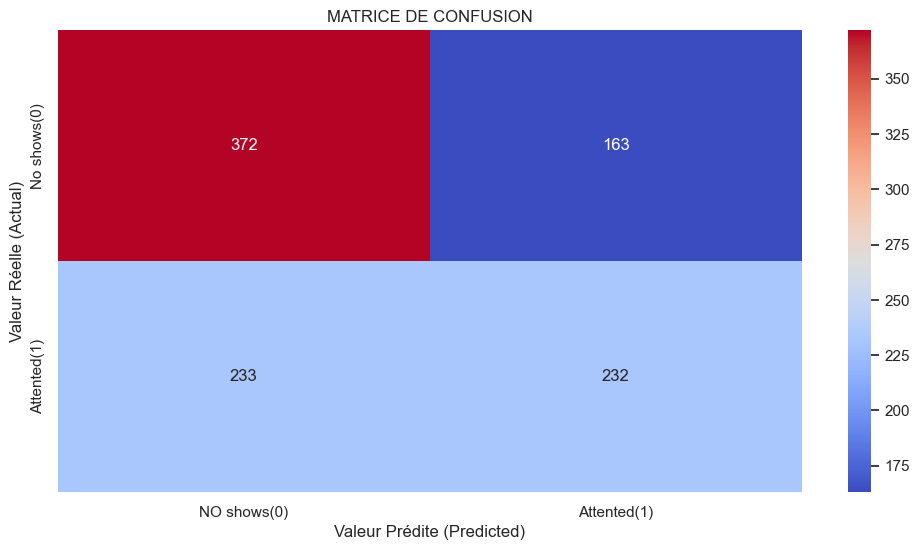

In [84]:
conf_m = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,6))
ax = sns.heatmap( conf_m ,
                  annot=True, 
                  fmt="d",
                  cmap="coolwarm",
                 xticklabels=["NO shows(0)", "Attented(1)"],
                  yticklabels=["No shows(0)", "Attented(1)"])
ax.set(
    xlabel="Valeur Prédite (Predicted)",
    ylabel="Valeur Réelle (Actual)",
    title="MATRICE DE CONFUSION",
)

plt.savefig("../image/EVALUATION/gboosting.png")
plt.show()




## FEATURE IMPORTANCE

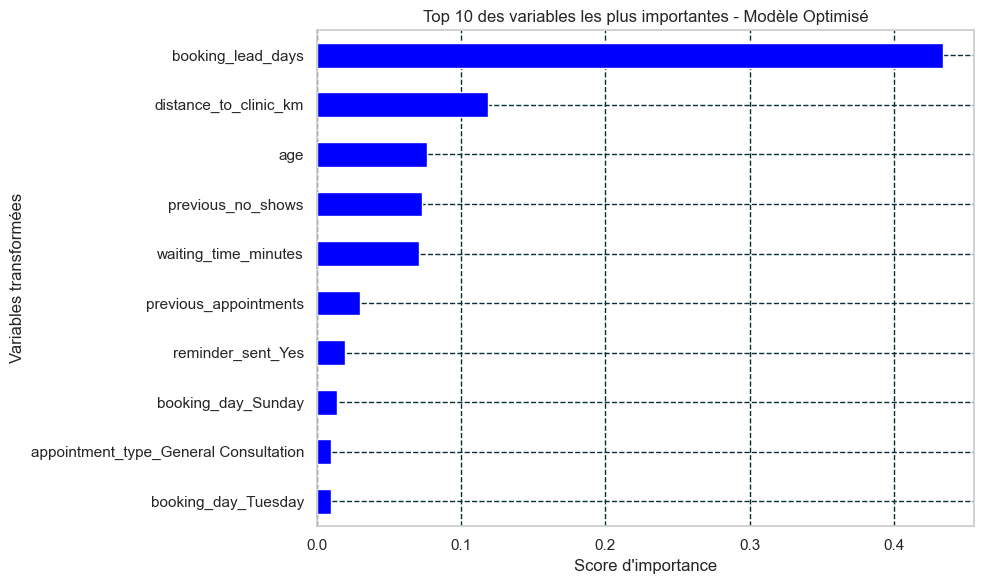

In [85]:


# 1. Récupérer les nouveaux noms de colonnes après transformation
noms_features = X_train.columns

# 2. Créer la Series avec les importances et les noms
importances = pd.Series(gradient_boost.feature_importances_, index=noms_features)

# 3. Sélectionner uniquement les 10 variables les plus importantes
top_10_importances = importances.nlargest(10)

# 4. Tracer le graphique en barres horizontales (triées par ordre croissant pour l'affichage)
plt.figure(figsize=(10, 6))
top_10_importances.sort_values().plot(kind="barh", color='blue')
plt.title("Top 10 des variables les plus importantes - Modèle Optimisé")
plt.xlabel("Score d'importance")
plt.ylabel("Variables transformées")
plt.tight_layout()
plt.savefig("../image/IMPORTANCE/gboosting.png")
plt.show()

## Forêt Aléatoire

In [90]:
rf_model = RandomForestClassifier(
class_weight='balanced',
criterion='gini', 
)

rf_model.fit(X_train, Y_train)
Y_pred = rf_model.predict(X_test)
print("#"* 50)
print(
    f"Accuracy Score: {accuracy_score(Y_test, Y_pred)} \n"
    f"Precision Score: {precision_score(Y_test, Y_pred)} \n"
    f"Recall Score: {recall_score(Y_test, Y_pred)} \n"
    f"F1 Score: {f1_score(Y_test, Y_pred)}"
)
metrics.append({ 
    "Model": "Random Forest",
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision Score": precision_score(Y_test, Y_pred),
    "Recall Score": recall_score(Y_test, Y_pred) ,
    "F1 Score": f1_score(Y_test, Y_pred)})

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


##################################################
Accuracy Score: 0.606 
Precision Score: 0.5847255369928401 
Recall Score: 0.5268817204301075 
F1 Score: 0.5542986425339367


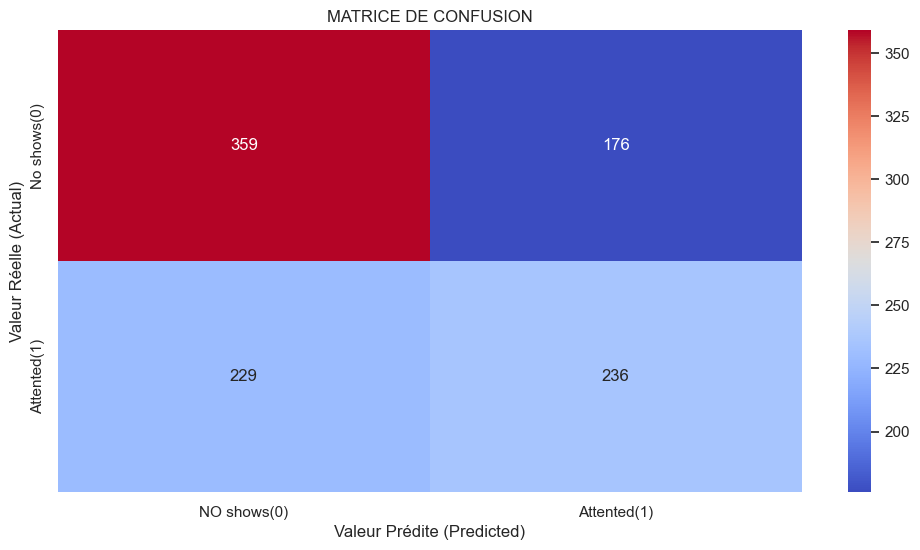

In [62]:
conf_m = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,6))
ax = sns.heatmap( conf_m ,
                  annot=True, 
                  fmt="d",
                  cmap="coolwarm",
                   xticklabels=["NO shows(0)", "Attented(1)"],
                  yticklabels=["No shows(0)", "Attented(1)"])
ax.set(
    xlabel="Valeur Prédite (Predicted)",
    ylabel="Valeur Réelle (Actual)",
    title="MATRICE DE CONFUSION",
)

plt.savefig("../image/EVALUATION/rforest.png")
plt.show()

## IMPORTANCE FEATURE

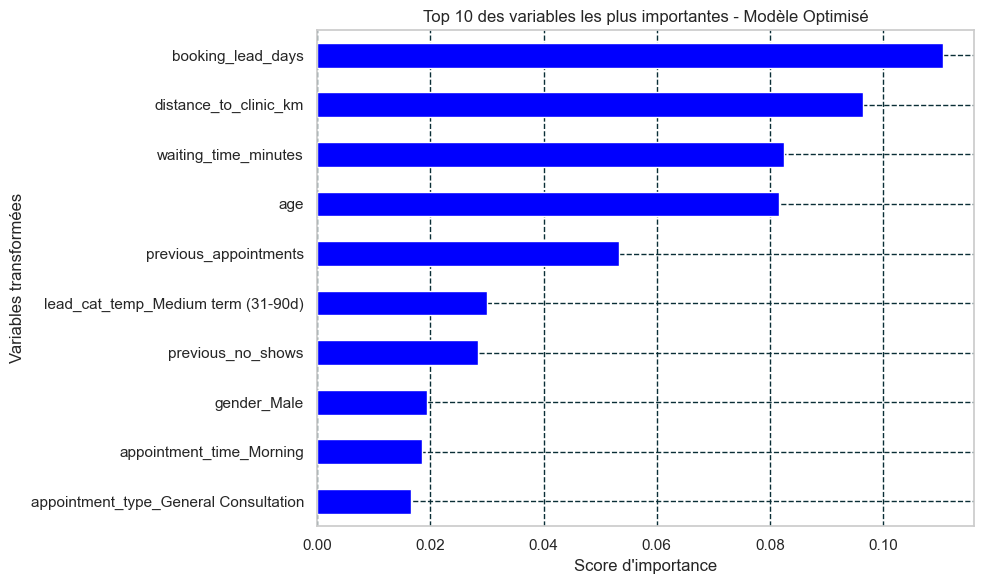

In [63]:


# 1. Récupérer les nouveaux noms de colonnes après transformation
noms_features = X_train.columns

# 2. Créer la Series avec les importances et les noms
importances = pd.Series(rf_model.feature_importances_, index=noms_features)

# 3. Sélectionner uniquement les 10 variables les plus importantes
top_10_importances = importances.nlargest(10)

# 4. Tracer le graphique en barres horizontales (triées par ordre croissant pour l'affichage)
plt.figure(figsize=(10, 6))
top_10_importances.sort_values().plot(kind="barh", color='blue')
plt.title("Top 10 des variables les plus importantes - Modèle Optimisé")
plt.xlabel("Score d'importance")
plt.ylabel("Variables transformées")
plt.tight_layout()
plt.savefig("../image/IMPORTANCE/RandomForest.png")
plt.show()

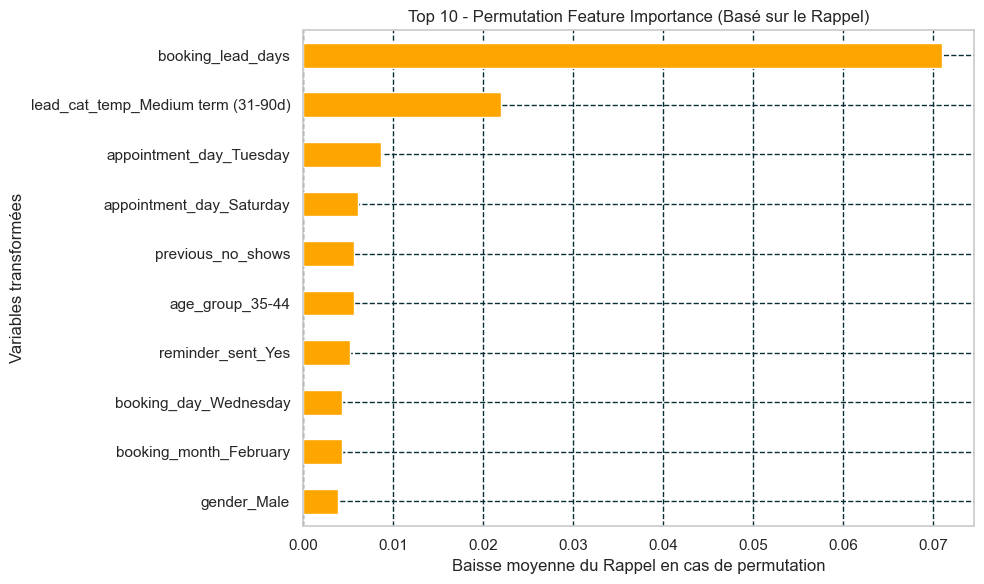

In [64]:


# 1. Calcul de la Permutation Feature Importance de manière optimisée pour le local
# (On utilise n_repeats=5 pour économiser le temps de calcul et les ressources)
resultat_perm = permutation_importance(
    rf_model,                  # Votre modèle entraîné (ex: best_rf ou autre)
    X_test,            # Vos données de test transformées
    Y_test,                   # Vos labels de test
    scoring='recall',         # On mesure l'impact sur LE RAPPEL (votre métrique clé)
    n_repeats=5,              # Nombre de permutations (légér pour le local)
    random_state=42,
    n_jobs=-1                 # Utilise tous les cœurs disponibles
)

# 2. Récupérer les noms des variables après transformation
noms_features = X_train.columns

# 3. Créer une Series propre avec les importances moyennes et trier
importances_perm = pd.Series(resultat_perm.importances_mean, index=noms_features)

# 4. Garder uniquement le Top 10 pour garder un graphique lisible
top_10_perm = importances_perm.nlargest(10)

# 5. Tracer le graphique du Top 10
plt.figure(figsize=(10, 6))
top_10_perm.sort_values().plot(kind="barh", color='orange')
plt.title("Top 10 - Permutation Feature Importance (Basé sur le Rappel)")
plt.xlabel("Baisse moyenne du Rappel en cas de permutation")
plt.ylabel("Variables transformées")
plt.savefig("../image/IMPORTANCE/RandomForest_featureI.png")
plt.tight_layout()

In [65]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


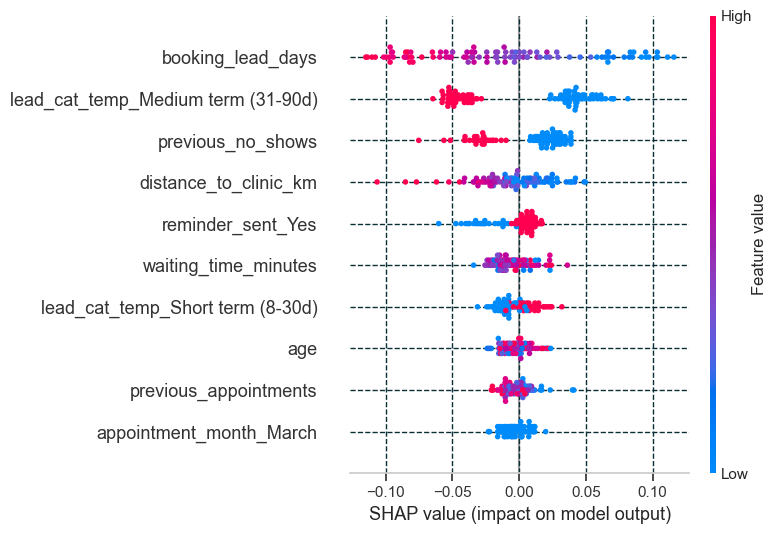

Explication détaillée pour une transaction spécifique :


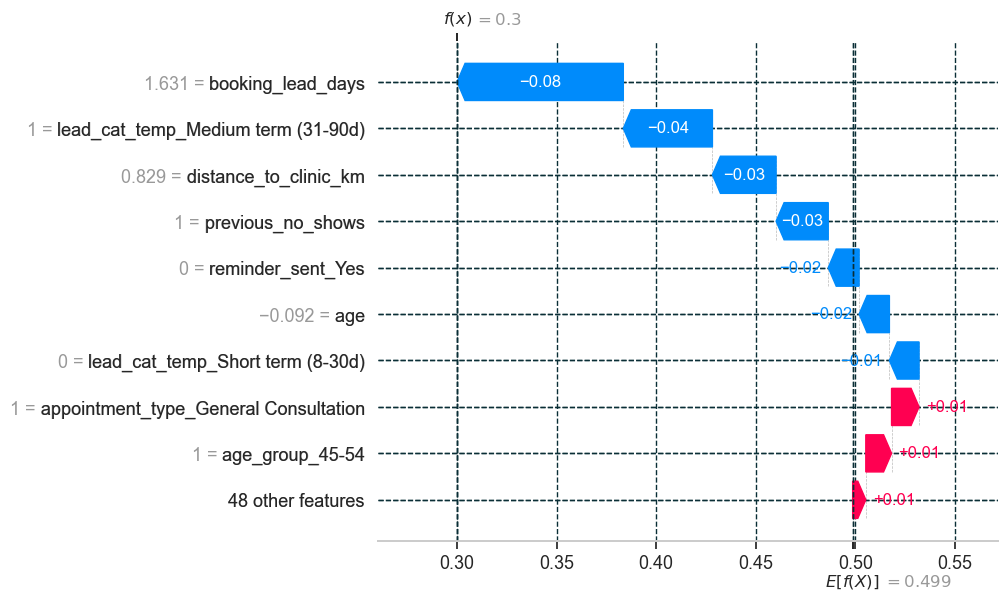

In [67]:
import numpy as np
import shap

# 1. Récupérer les noms des variables transformées
noms_features = X_train.columns

# 2. Créer l'explainer et calculer les valeurs SHAP
explainer = shap.TreeExplainer(rf_model)
X_test_sample = X_test[:100]
shap_values = explainer(X_test_sample)

# 3. Graphique global
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    feature_names=noms_features,
    max_display=10,
    show=True,
)
plt.savefig( "../image/IMPORTANCE/RandomForest_shap.png", bbox_inches="tight", dpi=300)
plt.close()

# ==========================================
# 4. Inférence locale corrigée pour le Waterfall
# ==========================================
print("Explication détaillée pour une transaction spécifique :")

# Pour un modèle de classification binaire, shap_values[0] contient les valeurs pour les deux classes.
# On extrait proprement les valeurs et la valeur de base (expected_value) pour la classe 1 (Fraude).
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

# On crée un objet Explanation propre pour le waterfall de la première ligne, classe 1
explication_unique = shap.Explanation(
    values=shap_values.values[0, :, 1],
    base_values=base_val,
    data=X_test_sample.iloc[0] if hasattr(X_test_sample, "iloc") else X_test_sample[0],
    feature_names=noms_features
)

# Génération du waterfall
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explication_unique, show=True)
plt.savefig( "../image/IMPORTANCE/RandomForest_shap_wtfall.png", bbox_inches="tight", dpi=300)
plt.close()


## ARBRE DE DECISION

In [91]:

dt_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',  
    random_state=42,
    min_samples_leaf=5
)

# 2. Entraînement sur les données transformées (X_train_transf)
# Note: Si vous utilisez l'arbre seul, vous pouvez tester avec X_train_transf ou X_train_resample
dt_model.fit(X_train, Y_train)

# 3. Prédiction sur le jeu de test
Y_pred = dt_model.predict(X_test)

# 4. Affichage des métriques
print("#"* 50)
print(
    f"Accuracy Score: {accuracy_score(Y_test, Y_pred)} \n"
    f"Precision Score: {precision_score(Y_test, Y_pred)} \n"
    f"Recall Score: {recall_score(Y_test, Y_pred)} \n"
    f"F1 Score: {f1_score(Y_test, Y_pred)}"
)

# 5. Sauvegarde dans votre liste de métriques
metrics.append({ 
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(Y_test, Y_pred),
    "Precision Score": precision_score(Y_test, Y_pred),
    "Recall Score": recall_score(Y_test, Y_pred),
    "F1 Score": f1_score(Y_test, Y_pred)
})

##################################################
Accuracy Score: 0.611 
Precision Score: 0.5926829268292683 
Recall Score: 0.5225806451612903 
F1 Score: 0.5554285714285714


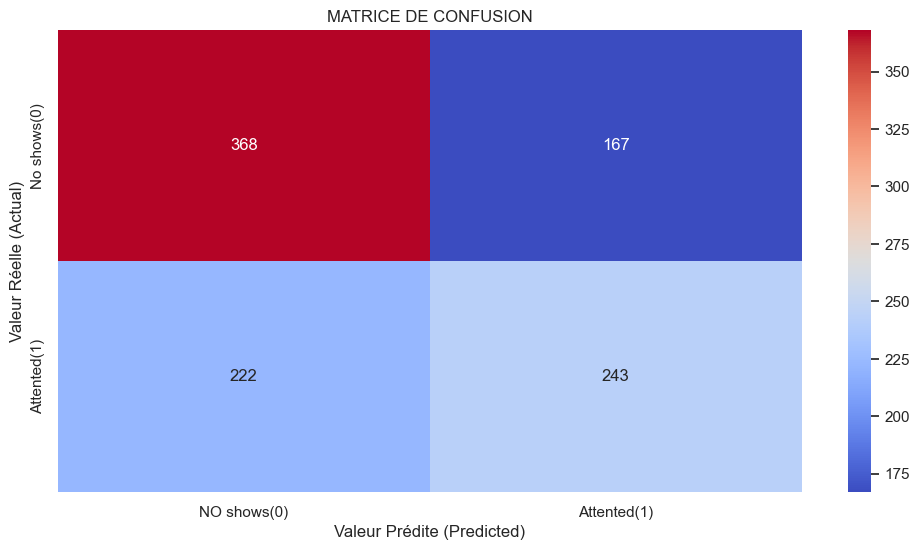

In [70]:
conf_m = confusion_matrix(Y_test,Y_pred)
plt.figure(figsize=(12,6))
ax = sns.heatmap( conf_m ,
                  annot=True, 
                  fmt="d",
                  cmap="coolwarm",
                  xticklabels=["NO shows(0)", "Attented(1)"],
                  yticklabels=["No shows(0)", "Attented(1)"])
ax.set(
    xlabel="Valeur Prédite (Predicted)",
    ylabel="Valeur Réelle (Actual)",
    title="MATRICE DE CONFUSION",
)

plt.savefig("../image/EVALUATION/Decision_tree.png")
plt.show()

## IMPORTANCE FEATURE

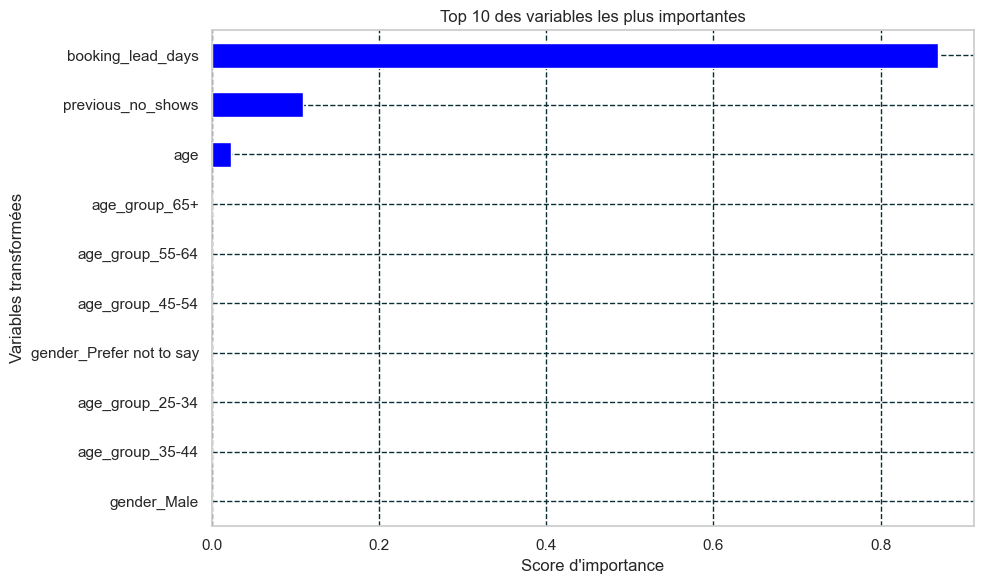

In [71]:


# 1. Récupérer les nouveaux noms de colonnes après transformation
noms_features = X_train.columns

# 2. Créer la Series avec les importances et les noms
importances = pd.Series(dt_model.feature_importances_, index=noms_features)

# 3. Sélectionner uniquement les 10 variables les plus importantes
top_10_importances = importances.nlargest(10)

# 4. Tracer le graphique en barres horizontales (triées par ordre croissant pour l'affichage)
plt.figure(figsize=(10, 6))
top_10_importances.sort_values().plot(kind="barh", color='blue')
plt.title("Top 10 des variables les plus importantes")
plt.xlabel("Score d'importance")
plt.ylabel("Variables transformées")
plt.tight_layout()
plt.savefig("../image/IMPORTANCE/Dtree.png")
plt.show()

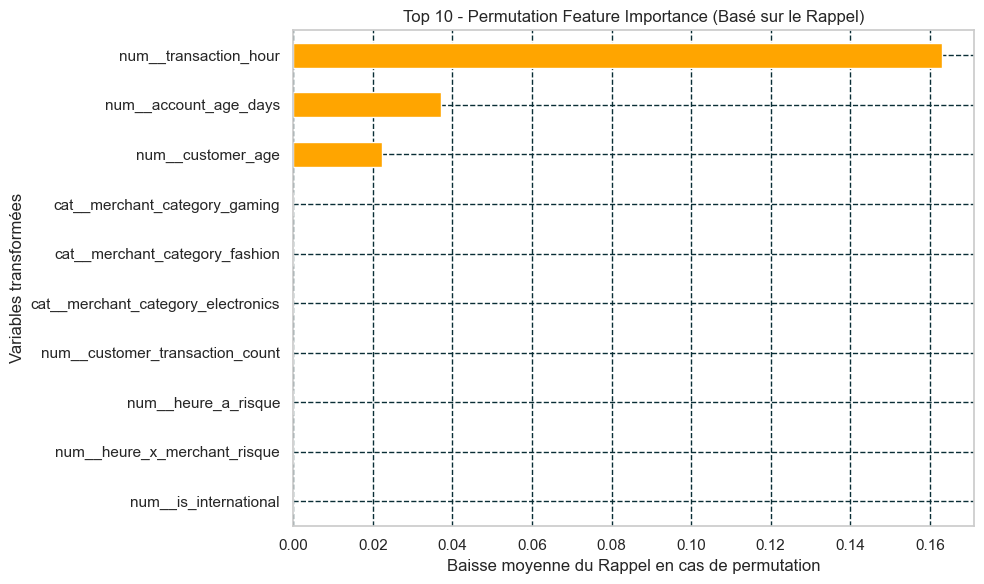

In [56]:
from sklearn.inspection import permutation_importance

# 1. Calcul de la Permutation Feature Importance de manière optimisée pour le local
# (On utilise n_repeats=5 pour économiser le temps de calcul et les ressources)
resultat_perm = permutation_importance(
    dt_model,                  # Votre modèle entraîné (ex: best_rf ou autre)
    X_test,            # Vos données de test transformées
    Y_test,                   # Vos labels de test
    scoring='recall',         # On mesure l'impact sur LE RAPPEL (votre métrique clé)
    n_repeats=5,              # Nombre de permutations (légér pour le local)
    random_state=42,
    n_jobs=-1                 # Utilise tous les cœurs disponibles
)

# 2. Récupérer les noms des variables après transformation
noms_features = preprocessor.get_feature_names_out()

# 3. Créer une Series propre avec les importances moyennes et trier
importances_perm = pd.Series(resultat_perm.importances_mean, index=noms_features)

# 4. Garder uniquement le Top 10 pour garder un graphique lisible
top_10_perm = importances_perm.nlargest(10)

# 5. Tracer le graphique du Top 10
plt.figure(figsize=(10, 6))
top_10_perm.sort_values().plot(kind="barh", color='orange')
plt.title("Top 10 - Permutation Feature Importance (Basé sur le Rappel)")
plt.xlabel("Baisse moyenne du Rappel en cas de permutation")
plt.ylabel("Variables transformées")
plt.savefig("../image/IMPORTANCE/DecisionTree_featureI.png")
plt.tight_layout()

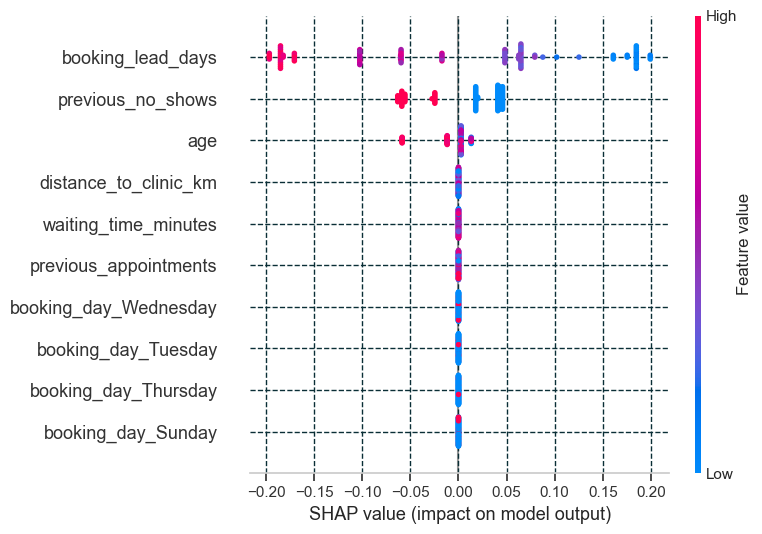

Explication détaillée pour une transaction spécifique :


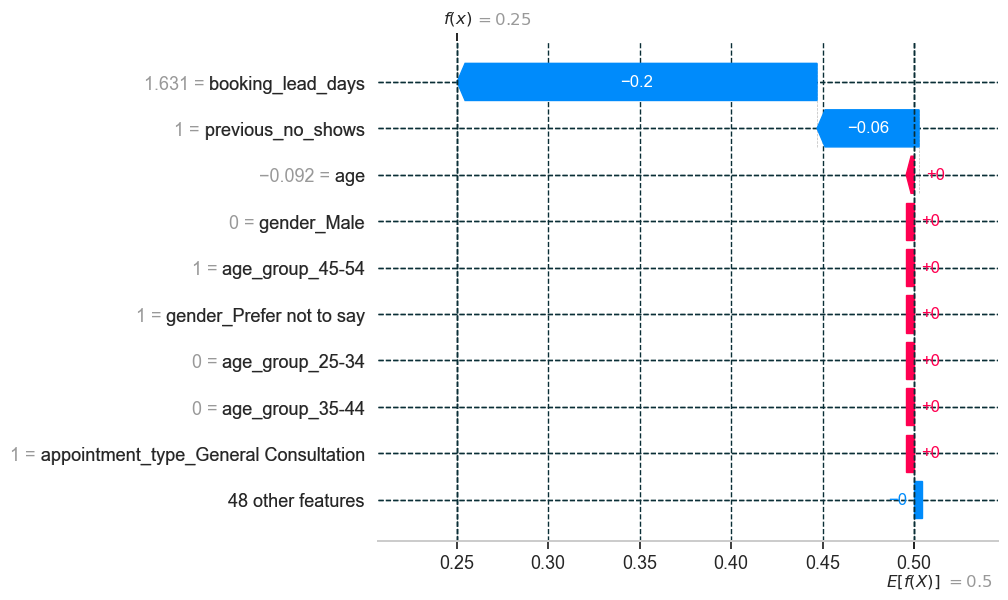

In [72]:

import shap

# 1. Récupérer les noms des variables transformées
noms_features = X_train.columns

# 2. Créer l'explainer et calculer les valeurs SHAP
explainer = shap.TreeExplainer(dt_model)
X_test_sample = X_test[:100]
shap_values = explainer(X_test_sample)

# 3. Graphique global
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_sample,
    feature_names=noms_features,
    max_display=10,
    show=True,
)
plt.savefig("../image/IMPORTANCE/DecisinTree_shap.png", bbox_inches="tight", dpi=300)
plt.close()

# ==========================================
# 4 Waterfall
# ==========================================
print("Explication détaillée pour une transaction spécifique :")

# Récupération sécurisée de la valeur de base pour la classe 1 (Fraude)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = explainer.expected_value[1]
else:
    base_val = explainer.expected_value

# Reconstruction propre d'un objet Explanation valide pour la première ligne (classe 1)
explication_unique = shap.Explanation(
    values=shap_values.values[0, :, 1],
    base_values=base_val,
    data=(
        X_test_sample.iloc[0]
        if hasattr(X_test_sample, "iloc")
        else X_test_sample[0]
    ),
    feature_names=noms_features,
)

# Génération et sauvegarde du waterfall
plt.figure(figsize=(10, 6))
shap.plots.waterfall(explication_unique, show=True)
plt.savefig("../image/IMPORTANCE/DecisinTree_shap_wtfll.png",bbox_inches="tight",dpi=300,)
plt.close()

## ROC_CURVE & PRECISION_RECALL_CURVE

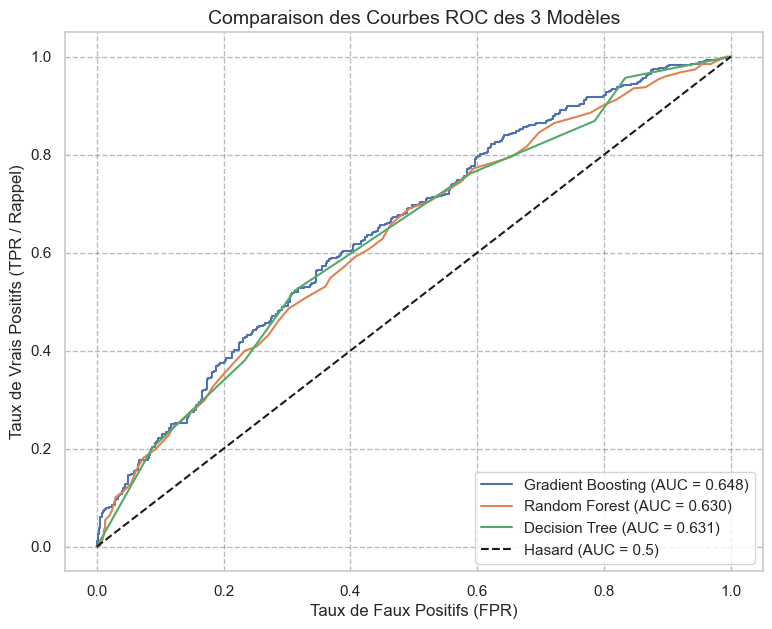

In [74]:

plt.figure(figsize=(9, 7))

# Liste de vos modèles entraînés
models = {
    "Gradient Boosting": gradient_boost,
    "Random Forest": rf_model,
    "Decision Tree": dt_model
}

for name, model in models.items():
    # Récupérer les probabilités de la classe 1
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculer le ROC-AUC
    auc_score = roc_auc_score(Y_test, y_pred_proba)
    
    # Calculer FPR et TPR
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    
    # Tracer la courbe
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

# Ligne diagonale du hasard
plt.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC = 0.5)')

plt.xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (TPR / Rappel)', fontsize=12)
plt.title('Comparaison des Courbes ROC des 3 Modèles', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("../image/EVALUATION/ROC-CURVE.png")
plt.show()

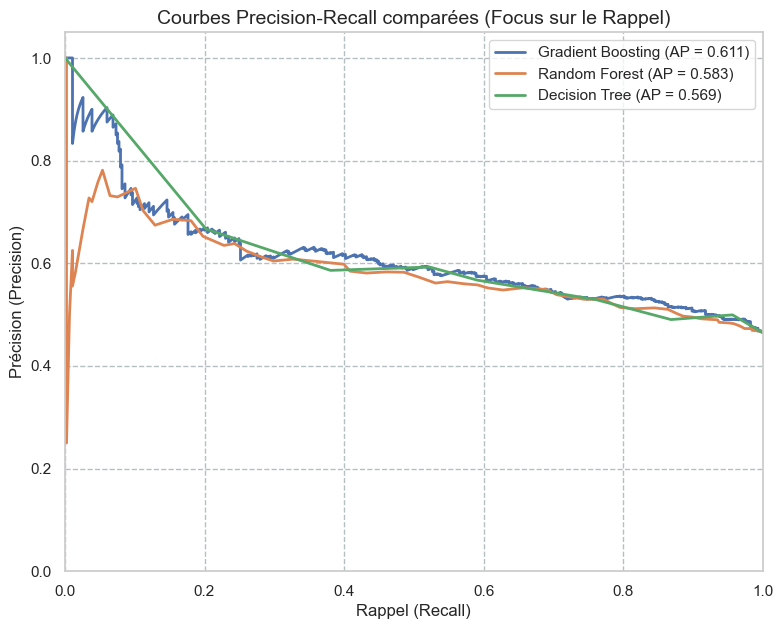

In [75]:



plt.figure(figsize=(9, 7))

# Dictionnaire de vos trois modèles entraînés
models = {
    "Gradient Boosting": gradient_boost,
    "Random Forest": rf_model,
    "Decision Tree": dt_model
}

for name, model in models.items():
    # 1. Récupérer les probabilités de la classe minoritaire (la classe 1)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 2. Calculer l'Average Precision (AP) pour résumer la performance dans la légende
    ap_score = average_precision_score(Y_test, y_pred_proba)
    
    # 3. Calculer la précision, le rappel et les seuils
    precision, recall, thresholds = precision_recall_curve(Y_test, y_pred_proba)
    
    # 4. Tracer la courbe (Rappel en X, Précision en Y)
    plt.plot(recall, precision, lw=2, label=f"{name} (AP = {ap_score:.3f})")

# Configuration du graphique
plt.xlabel('Rappel (Recall)', fontsize=12)
plt.ylabel('Précision (Precision)', fontsize=12)
plt.title('Courbes Precision-Recall comparées (Focus sur le Rappel)', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="upper right", fontsize=11)
plt.grid(alpha=0.3)
plt.savefig("../image/EVALUATION/ Precision-Recall.png")
plt.show()

In [92]:
compare = pd.DataFrame(metrics, index=["gradient boosting","Forêt aléatoire","Arbre de décision"])

In [93]:
compare.style.background_gradient(
    cmap="viridis", 
    subset=["Accuracy", "Precision Score", "Recall Score", "F1 Score"]
)

,Accuracy,Precision Score,Recall Score,F1 Score,Model
gradient boosting,0.605000,0.588384,0.501075,0.541231,nan
Forêt aléatoire,0.606000,0.584726,0.526882,0.554299,Random Forest
Arbre de décision,0.611000,0.592683,0.522581,0.555429,Decision Tree


In [94]:
import joblib

# 2. Sauvegarder l'Arbre de décision et la Forêt aléatoire directement depuis votre dictionnaire
joblib.dump(models["Decision Tree"], '../models/decision_tree.pkl')
joblib.dump(models["Random Forest"], '../models/random_forest.pkl')

['../models/random_forest.pkl']